#**Data Loading and Initial Look**

In [545]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc, accuracy_score
from sklearn.metrics import confusion_matrix

In [546]:
#Upload the training set
df_train = pd.read_csv('training.csv')
df_train.head(5)

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


In [547]:
df_train.shape

(12906, 83)

In [548]:
df_train.describe()

,patient_id,patient_zip3,patient_age,bmi,population,density,age_median,age_under_10,age_10_to_19,age_20s,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
count,12906.000000,12906.000000,12906.000000,3941.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,12905.000000,...,12905.000000,12902.000000,12902.000000,12905.000000,12905.000000,12905.000000,12877.000000,12877.000000,12877.000000,12906.000000
mean,547381.196033,573.754300,59.183326,28.984539,20744.441237,1581.950419,40.502259,11.122784,12.945265,13.290376,...,13.335299,13.406950,4.474956,27.978387,8.575284,7.083376,39.822352,7.475221,16.098988,0.624516
std,260404.959974,275.447534,13.335216,5.696906,13886.903756,2966.305306,4.036963,1.512376,1.923974,3.354103,...,3.690949,5.222495,4.837085,5.083939,4.203482,3.109022,3.559492,1.516499,5.842501,0.484266
min,100063.000000,101.000000,18.000000,14.000000,635.545455,0.916667,20.600000,0.000000,6.314286,5.925000,...,4.600000,3.433333,0.000000,12.460784,2.440000,1.200000,30.939316,2.636008,2.760371,0.000000
25%,321517.000000,331.000000,50.000000,24.660000,9463.896552,171.857143,37.129825,10.160000,11.741176,11.013415,...,10.270492,9.663333,0.994444,24.933333,5.618750,4.929688,37.698880,6.651215,11.280694,0.000000
50%,543522.000000,554.000000,59.000000,28.190000,19154.190480,700.337500,40.639344,11.039216,12.923944,12.538095,...,12.884000,12.177778,2.747222,27.788235,7.465714,6.847059,39.108249,7.686577,15.589148,1.000000
75%,772671.750000,846.000000,67.000000,32.920000,30021.278690,1666.515385,42.934783,12.190000,14.019767,14.971053,...,15.555405,16.635556,5.976000,30.709375,10.617442,8.620000,41.136513,8.276922,20.801880,1.000000
max,999896.000000,999.000000,91.000000,85.000000,71374.131580,21172.000000,54.570000,17.675000,35.300000,62.100000,...,35.155556,38.347826,26.755000,48.020000,27.566102,25.200000,52.237210,11.169408,31.504775,1.000000


In [549]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 83 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             12906 non-null  int64  
 1   patient_race                           6521 non-null   object 
 2   payer_type                             11103 non-null  object 
 3   patient_state                          12855 non-null  object 
 4   patient_zip3                           12906 non-null  int64  
 5   patient_age                            12906 non-null  int64  
 6   patient_gender                         12906 non-null  object 
 7   bmi                                    3941 non-null   float64
 8   breast_cancer_diagnosis_code           12906 non-null  object 
 9   breast_cancer_diagnosis_desc           12906 non-null  object 
 10  metastatic_cancer_diagnosis_code       12906 non-null  object 
 11  me




---


*   Object (11) = Categorical
* Float (68) or Int (4) = Numerical


---





In [550]:
# Check for missing values
missing_values = df_train.isnull().sum()
print("\nMissing Values per Feature:\n", missing_values)


Missing Values per Feature:
 patient_id           0
patient_race      6385
payer_type        1803
patient_state       51
patient_zip3         0
                  ... 
veteran              1
Ozone               29
PM25                29
N02                 29
DiagPeriodL90D       0
Length: 83, dtype: int64


In [551]:
# Is there any missing values?
np.any(df_train.isnull())

np.True_

In [552]:
print(df_train.describe(include='all'))

           patient_id patient_race  payer_type patient_state  patient_zip3  \
count    12906.000000         6521       11103         12855  12906.000000   
unique            NaN            5           3            50           NaN   
top               NaN        White  COMMERCIAL            CA           NaN   
freq              NaN         3588        6032          2438           NaN   
mean    547381.196033          NaN         NaN           NaN    573.754300   
std     260404.959974          NaN         NaN           NaN    275.447534   
min     100063.000000          NaN         NaN           NaN    101.000000   
25%     321517.000000          NaN         NaN           NaN    331.000000   
50%     543522.000000          NaN         NaN           NaN    554.000000   
75%     772671.750000          NaN         NaN           NaN    846.000000   
max     999896.000000          NaN         NaN           NaN    999.000000   

         patient_age patient_gender          bmi breast_cancer_

In [553]:
summary = []
for col in df_train.columns:
    dtype = df_train[col].dtype
    is_categorical = dtype == 'object' or df_train[col].nunique() < 20
    if is_categorical:
        values = ", ".join(map(str, df_train[col].dropna().unique()))
        summary.append([
            col, 'Categorical', values,
            missing_values[col], 'N/A'
        ])
    else:
        col_min = df_train[col].min()
        col_max = df_train[col].max()
        outliers = df_train[(df_train[col] < (df_train[col].quantile(0.25) - 1.5 * (df_train[col].quantile(0.75) - df_train[col].quantile(0.25)))) |
                      (df_train[col] > (df_train[col].quantile(0.75) + 1.5 * (df_train[col].quantile(0.75) - df_train[col].quantile(0.25))))]
        summary.append([
            col, 'Numerical', f"{col_min} to {col_max}",
            missing_values[col], len(outliers)
        ])

summary_df = pd.DataFrame(summary, columns=[
    "Feature", "Type", "Values/Range", "Missing Values", "Outliers"
])
print("\nFeature Summary Table:")
print(summary_df)


Feature Summary Table:
           Feature         Type  \
0       patient_id    Numerical   
1     patient_race  Categorical   
2       payer_type  Categorical   
3    patient_state  Categorical   
4     patient_zip3    Numerical   
..             ...          ...   
78         veteran    Numerical   
79           Ozone    Numerical   
80            PM25    Numerical   
81             N02    Numerical   
82  DiagPeriodL90D  Categorical   

                                         Values/Range  Missing Values Outliers  
0                                    100063 to 999896               0        0  
1                White, Other, Hispanic, Asian, Black            6385      N/A  
2            MEDICAID, COMMERCIAL, MEDICARE ADVANTAGE            1803      N/A  
3   CA, TX, ID, NY, IL, MI, OR, MT, KY, OH, IN, FL...              51      N/A  
4                                          101 to 999               0        0  
..                                                ...             ...



---

## **Classification Imbalance**

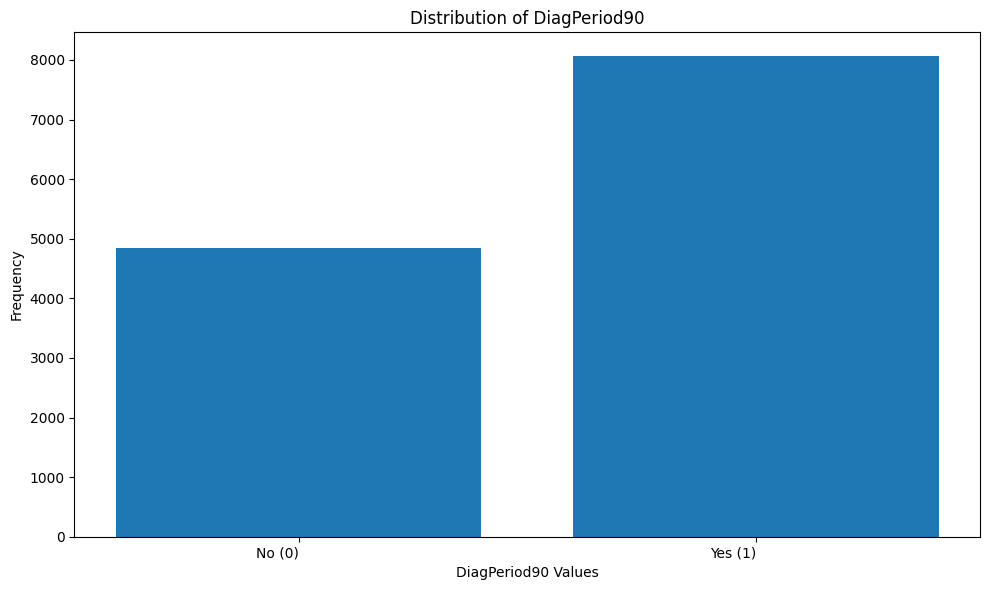

In [554]:
diag_period_90_data = df_train['DiagPeriodL90D']

diag_period_90_counts = diag_period_90_data.value_counts()

plt.figure(figsize=(10, 6))
plt.bar(diag_period_90_counts.index, diag_period_90_counts.values)
plt.xlabel("DiagPeriod90 Values")
plt.ylabel("Frequency")
plt.title("Distribution of DiagPeriod90")
plt.xticks(diag_period_90_counts.index, ['Yes (1)', 'No (0)'])
plt.xticks(rotation=0, ha='right')
plt.tight_layout()

In [555]:
target_col = df_train.columns[-1]
target_col = df_train.columns[-1]
print(f"\nTarget column: {target_col}")
print("Value counts:\n", df_train[target_col].value_counts())
print("Encoded as:", df_train[target_col].unique())


Target column: DiagPeriodL90D
Value counts:
 DiagPeriodL90D
1    8060
0    4846
Name: count, dtype: int64
Encoded as: [1 0]




---
# **Data Visualization (Before Cleaning)**


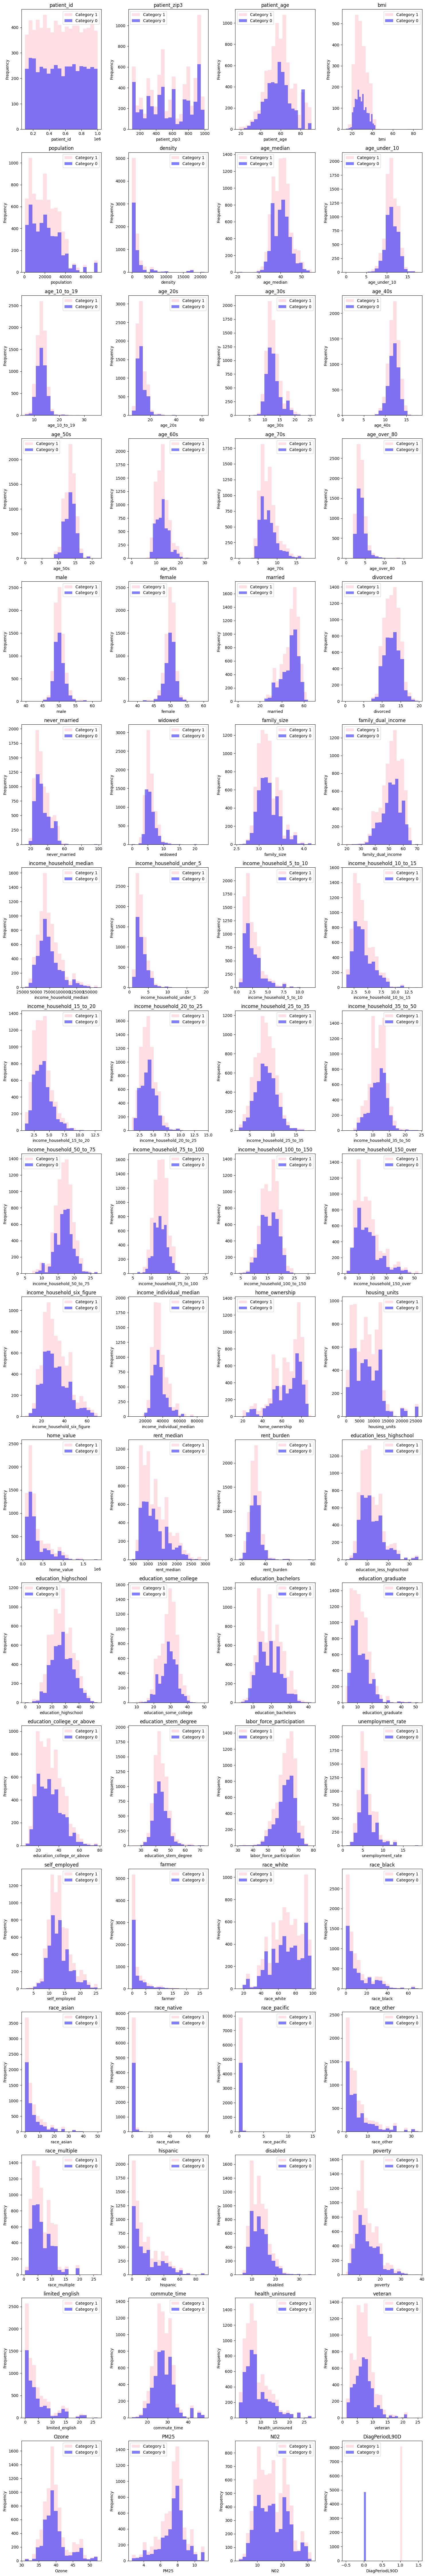

In [556]:
numerical_columns = df_train.select_dtypes(include=['float64', 'int64']).columns

categorical_feature = 'DiagPeriodL90D'
categories = df_train[categorical_feature].unique()
colors = ['pink', 'blue']

n_columns = 4
n_rows = int(np.ceil(len(numerical_columns) / n_columns))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_columns, start=1):
    plt.subplot(n_rows, n_columns, i)
    for j, category in enumerate(categories):
        category_data = df_train[df_train[categorical_feature] == category]
        plt.hist(category_data[col], bins=20, color=colors[j], alpha=0.5, label=f'Category {category}')

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()



---


# **Data Cleaning and Preperation**


## **Duplicates**

In [557]:
# Check for duplicates across all columns
duplicates = df_train[df_train.duplicated()]
print("Number of duplicate rows:", duplicates.shape[0])

Number of duplicate rows: 0




---

## **Missing Values**

In [558]:
# Calculate missing values for each column
missing_values = df_train.isnull().sum()

# Filter for numerical columns with missing values
numerical_cols_with_missing = missing_values[(missing_values > 0) & (df_train.dtypes != 'object')].index.tolist()

# Print the result
print("Numerical columns with missing values:", numerical_cols_with_missing)

Numerical columns with missing values: ['bmi', 'population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'education_less_highschool', 'education_highschool', 'education_some_college', 'education_bachelors', 'education_graduate', 'education_college_or_above', 'education_stem_degree', 'labor_force_participation', 'u

In [559]:
# Calculate missing values for each column
missing_values = df_train.isnull().sum()

# Filter for numerical columns with missing values
numerical_cols_with_missing = missing_values[(missing_values > 0) & (df_train.dtypes != 'object')].index.tolist()

# Print the result
print("Numerical columns with missing values:", numerical_cols_with_missing)

# Calculate and print missing values for each numerical column with missing values
for col in numerical_cols_with_missing:
    missing_count = df_train[col].isnull().sum()
    print(f"Number of missing values in {col}: {missing_count}")

Numerical columns with missing values: ['bmi', 'population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'education_less_highschool', 'education_highschool', 'education_some_college', 'education_bachelors', 'education_graduate', 'education_college_or_above', 'education_stem_degree', 'labor_force_participation', 'u

In [560]:
missing_values = df_train.isnull().sum()
numerical_cols_with_missing = missing_values[
    (missing_values > 0) & (missing_values < 50) & (df_train.dtypes != 'object')
].index.tolist()

print("Numerical columns with less than 50 missing values:", numerical_cols_with_missing)

for col in numerical_cols_with_missing:
    median_value = df_train[col].median()
    df_train.fillna({col:median_value}, inplace=True)


Numerical columns with less than 50 missing values: ['population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'education_less_highschool', 'education_highschool', 'education_some_college', 'education_bachelors', 'education_graduate', 'education_college_or_above', 'education_stem_degree', 'labor_force_participatio

In [561]:
# Calculate missing values for each column
missing_values = df_train.isnull().sum()

# Filter for categorical columns with missing values
categorical_cols_with_missing = missing_values[(missing_values > 0) & (df_train.dtypes == 'object')].index.tolist()

# Print the result
print("Categorical columns with missing values:", categorical_cols_with_missing)

# Calculate and print missing values for each categorical column with missing values
for col in categorical_cols_with_missing:
    missing_count = df_train[col].isnull().sum()
    print(f"Number of missing values in {col}: {missing_count}")

Categorical columns with missing values: ['patient_race', 'payer_type', 'patient_state', 'metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type', 'Region', 'Division']
Number of missing values in patient_race: 6385
Number of missing values in payer_type: 1803
Number of missing values in patient_state: 51
Number of missing values in metastatic_first_novel_treatment: 12882
Number of missing values in metastatic_first_novel_treatment_type: 12882
Number of missing values in Region: 52
Number of missing values in Division: 52


In [562]:
#Replace missing values with other for payer type
df_train.fillna({'payer_type':'Other'}, inplace=True)

In [563]:
# Replace missing values in 'patient_race' with 'Other'
df_train.fillna({'patient_race':'Other'}, inplace=True)

### Distributions





---

## **Drop Columns**

In [564]:
columns_to_drop = [
    'patient_id',
    'patient_gender',
    'bmi',
    'metastatic_first_novel_treatment',
    'metastatic_first_novel_treatment_type',
    'breast_cancer_diagnosis_code',
    'breast_cancer_diagnosis_desc',
    'metastatic_cancer_diagnosis_code',
    'patient_state',
    'patient_zip3',
    'Region',
    'Division'
]
df_train.drop(columns=columns_to_drop, inplace=True)



---
## **Outliers**


In [565]:
def find_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

numerical_cols = df_train.select_dtypes(include=['number']).columns

for col in numerical_cols:
    outliers = find_outliers_IQR(df_train, col)
    num_outliers = len(outliers)
    print(f"Column '{col}' has {num_outliers} outliers.")

Column 'patient_age' has 44 outliers.
Column 'population' has 192 outliers.
Column 'density' has 1092 outliers.
Column 'age_median' has 62 outliers.
Column 'age_under_10' has 171 outliers.
Column 'age_10_to_19' has 254 outliers.
Column 'age_20s' has 391 outliers.
Column 'age_30s' has 375 outliers.
Column 'age_40s' has 141 outliers.
Column 'age_50s' has 131 outliers.
Column 'age_60s' has 222 outliers.
Column 'age_70s' has 316 outliers.
Column 'age_over_80' has 470 outliers.
Column 'male' has 549 outliers.
Column 'female' has 549 outliers.
Column 'married' has 153 outliers.
Column 'divorced' has 26 outliers.
Column 'never_married' has 26 outliers.
Column 'widowed' has 319 outliers.
Column 'family_size' has 142 outliers.
Column 'family_dual_income' has 94 outliers.
Column 'income_household_median' has 703 outliers.
Column 'income_household_under_5' has 299 outliers.
Column 'income_household_5_to_10' has 555 outliers.
Column 'income_household_10_to_15' has 301 outliers.
Column 'income_hous

In [566]:
def replace_outliers(df, column):
    mean = df[column].mean()
    median = df[column].median()

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    if mean > median:
        replacement_value = median
    else:
        replacement_value = mean

    df.loc[outliers.index, column] = replacement_value

numerical_cols = df_train.select_dtypes(include=['number']).columns
for col in numerical_cols:
    replace_outliers(df_train, col)
print("Outliers replaced based on mean and median comparison.")

Outliers replaced based on mean and median comparison.




---

### **MultiCorrleated Heatmap**

In [567]:
categorical_cols = df_train.select_dtypes(include=['object']).columns
label_encoder = LabelEncoder()

# Applying Label Encoding
for col in categorical_cols:
    df_train[col] = label_encoder.fit_transform(df_train[col])

df_train.head()

,patient_race,payer_type,patient_age,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,3,1,84,31437.75000,1189.562500,30.642857,11.039216,15.542857,17.614286,14.014286,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,39.108249,8.650555,18.606528,1
1,4,0,62,39121.87879,2295.939394,38.200000,11.878788,13.354545,14.230303,13.418182,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,4,0,43,21996.68333,626.236667,37.906667,13.028333,14.463333,12.531667,13.545000,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,4,0,45,32795.32558,1896.220930,42.871429,10.071429,12.135714,12.538095,12.464286,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,3,0,55,10886.26000,116.886000,43.473469,10.824000,13.976000,9.492000,10.364000,...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,7.475696,11.722197,0


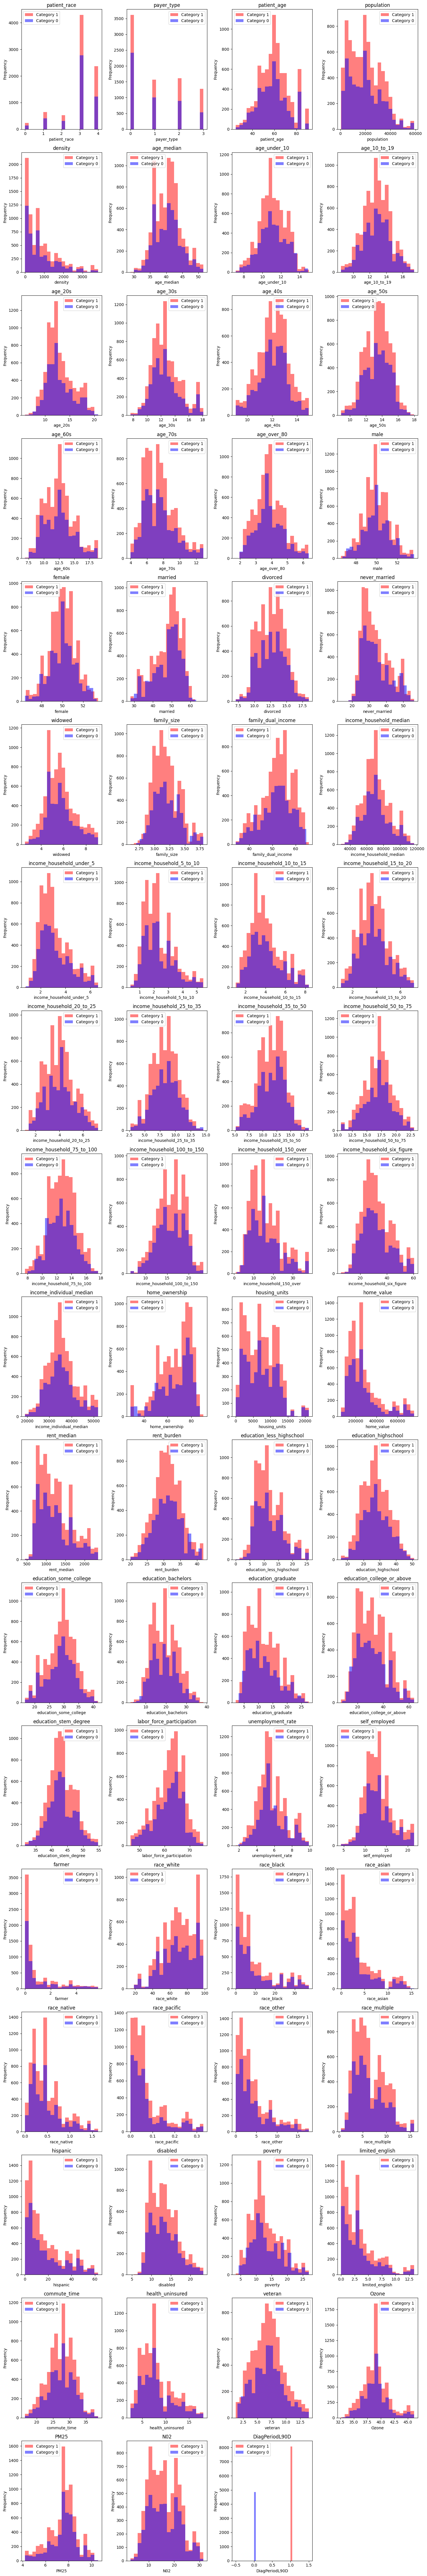

In [568]:
numerical_columns = df_train.select_dtypes(include=['float64', 'int64']).columns

categorical_feature = 'DiagPeriodL90D'
categories = df_train[categorical_feature].unique()
colors = ['red', 'blue']

n_columns = 4
n_rows = int(np.ceil(len(numerical_columns) / n_columns))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_columns, start=1):
    plt.subplot(n_rows, n_columns, i)
    for j, category in enumerate(categories):
        category_data = df_train[df_train[categorical_feature] == category]
        plt.hist(category_data[col], bins=20, color=colors[j], alpha=0.5, label=f'Category {category}')

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

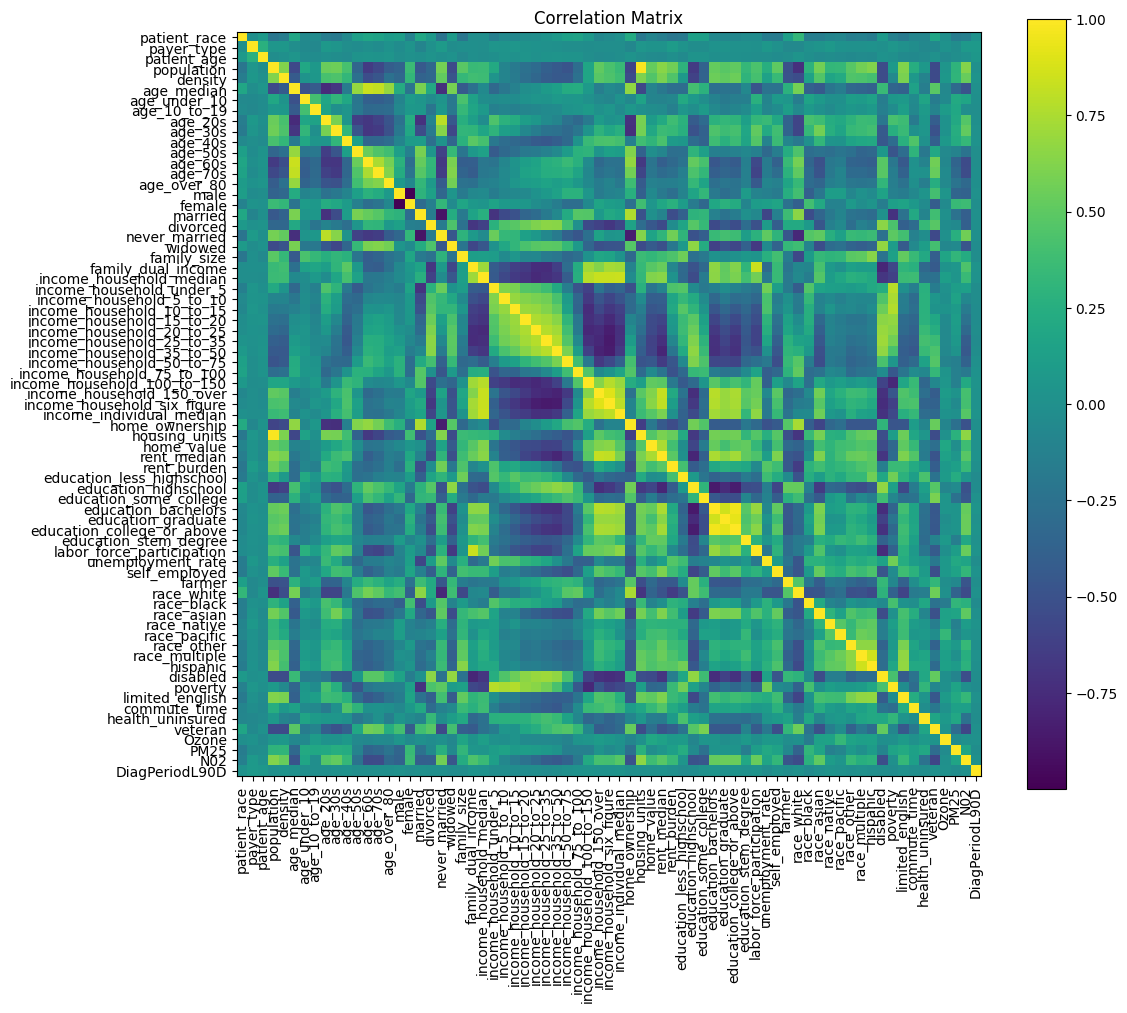

In [569]:
correlation_matrix = df_train.corr()
correlation_matrix

# Heat Map
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.show()



---


# **Machine Learning**

In [570]:
y = df_train['DiagPeriodL90D']
y.value_counts(normalize=True)

,proportion
DiagPeriodL90D,
1,0.624516
0,0.375484


In [ ]:
X = df_train.drop('DiagPeriodL90D', axis=1)
y = df_train['DiagPeriodL90D']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [572]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [573]:
print("Class balance after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Class balance after SMOTE:
DiagPeriodL90D
0    6443
1    6443
Name: count, dtype: int64


## **Decision Tree**

In [574]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train_resampled, y_train_resampled)

dt_val_preds = dt_model.predict(X_test)
dt_val_probs = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results:")
print(classification_report(y_test, dt_val_preds))
print("Validation ROC-AUC:", roc_auc_score(y_test, dt_val_probs))
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_val_preds))


Decision Tree Results:
              precision    recall  f1-score   support

           0       0.39      0.45      0.42       965
           1       0.64      0.59      0.61      1617

    accuracy                           0.54      2582
   macro avg       0.52      0.52      0.52      2582
weighted avg       0.55      0.54      0.54      2582

Validation ROC-AUC: 0.5207122509861222
Confusion Matrix:
[[437 528]
 [671 946]]




---

 ## **Random Forest**

In [575]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

val_preds = model.predict(X_test)
val_probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, val_preds))
print("Validation ROC-AUC:", roc_auc_score(y_test, val_probs))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, val_preds)
print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

           0       0.41      0.43      0.42       965
           1       0.65      0.62      0.63      1617

    accuracy                           0.55      2582
   macro avg       0.53      0.53      0.53      2582
weighted avg       0.56      0.55      0.55      2582

Validation ROC-AUC: 0.5512059369202226
Confusion Matrix:
[[ 418  547]
 [ 612 1005]]


- **Top left cell (418)** represents the true negatives (TN): the number of observations correctly predicted there diagnosis period was not less than 90 days  (0).

- **The top right cell (547)** represents the false positives (FP): the number of observations incorrectly predicted diagnosis period being less than 90 days (1) when the diagnosis period was not (0).

- **The bottom left cell (612)** represents the false negatives (FN): the number of observations incorrectly predicted as diagnosis period being not less than 90 days (0) when they actually was less than 90 days (1).

- **The bottom right cell (1005)** represents the true positives (TP): the number of observations correctly predicted diagnosis as less than 90 days (1).



---


## **XGB Boost**

In [576]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_val_preds = xgb_model.predict(X_test)
xgb_val_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, xgb_val_preds))
print("Validation ROC-AUC:", roc_auc_score(y_test, xgb_val_probs))
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_val_preds))


XGBoost Results:
              precision    recall  f1-score   support

           0       0.44      0.50      0.46       965
           1       0.67      0.62      0.64      1617

    accuracy                           0.57      2582
   macro avg       0.55      0.56      0.55      2582
weighted avg       0.58      0.57      0.58      2582

Validation ROC-AUC: 0.5820937513017453
Confusion Matrix:
[[479 486]
 [621 996]]


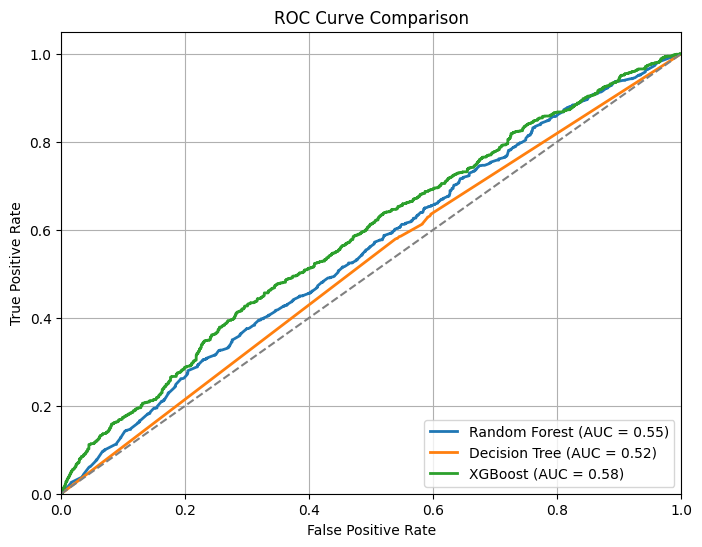

In [577]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, val_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_val_probs)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_val_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot all curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
